# 01 · First Contact

**Session 1 · Tue Sep 15 · 2 hours**

### Why this notebook exists

By the end of it you will have done the four things you will do in *every* data assignment for the
next eight weeks: load a file, look at its shape, summarise it, and draw one picture. Everything
later in the course is a variation on these four moves.

There is no statistics in this notebook. That is deliberate. Today is about making the tools stop
being in your way.

### How to use a notebook

- Click a grey cell and press **Shift+Enter** to run it. Output appears underneath.
- Cells share memory top to bottom. If something breaks, run from the top again.
- You cannot break anything permanently. The data files are regenerated by `make_data.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

That cell imported your tools. In plain English:

| Line | What it gives you |
|---|---|
| `numpy as np` | fast arrays and random numbers |
| `pandas as pd` | spreadsheet-like tables, called *DataFrames* |
| `matplotlib.pyplot as plt` | plotting |
| `seaborn as sns` | prettier plotting, built on matplotlib |
| `rng` | a random number generator with a fixed seed, so your numbers match mine |

`as np` just means "I'll call it `np` from now on" — it saves typing. Nothing deeper.

## 1 · Load a file

`pd.read_csv` reads a comma-separated file into a DataFrame. This is the single most-used function in
applied data work.

In [2]:
deposits = pd.read_csv(DATA / "branch_deposits.csv")
deposits.head()      # .head() shows the first 5 rows

,account_id,branch,product,balance,tenure_years
0,AC00000,Logan,Savings,4383.34,9.4
1,AC00001,Provo,Checking,9059.38,7.7
2,AC00002,Logan,Checking,6916.25,10.4
3,AC00003,Logan,Savings,5393.50,7.4
4,AC00004,Provo,Savings,1068.11,3.4


**Read the output as a table.** Each row is one *observation* (here, one account). Each column is one
*variable*. That vocabulary matters — lectures will say "observation" and "variable" constantly, and
they mean row and column.

## 2 · How big is it?

In [3]:
print("shape (rows, columns):", deposits.shape)
print("number of rows, n =", len(deposits))
print()
print("column names and types:")
print(deposits.dtypes)

shape (rows, columns): (1200, 5)
number of rows, n = 1200

column names and types:
account_id          str
branch              str
product             str
balance         float64
tenure_years    float64
dtype: object


`deposits.shape` gives `(1200, 5)` — 1,200 rows and 5 columns.

**That first number is `n`.** When a lecture writes `n = 1200`, this is what it means: how many
observations you have. You will see `n` in almost every formula in this course, and it is never more
complicated than "how many rows."

## 3 · Summarise it

In [4]:
deposits.describe()

,balance,tenure_years
count,1200.000000,1200.000000
mean,24072.128775,6.083917
std,106225.735073,4.299958
min,226.400000,0.100000
25%,1966.297500,2.900000
50%,3887.630000,5.200000
75%,7369.955000,8.125000
max,897660.840000,37.800000


This is your first real statistical output, so let's decode every row of it:

| Row | Meaning | Notation |
|---|---|---|
| `count` | how many non-missing values | `n` |
| `mean` | the average | `x̄` ("x-bar") |
| `std` | standard deviation — typical distance from the mean | `s` or `σ` |
| `min` / `max` | smallest and largest |  |
| `25%` / `50%` / `75%` | quartiles; `50%` is the **median** |  |

Now look hard at the `balance` column, and compare `mean` with `50%` (the median).

In [5]:
print(f"mean balance:   ${deposits.balance.mean():>10,.0f}")
print(f"median balance: ${deposits.balance.median():>10,.0f}")
print(f"the mean is {deposits.balance.mean() / deposits.balance.median():.1f}x the median")

mean balance:   $    24,072
median balance: $     3,888
the mean is 6.2x the median


### Stop and think about that

The mean is about six times the median. Both are called "the average" in everyday speech, and here
they disagree by a factor of six.

That is not a bug in the data. It is the most important practical fact in descriptive statistics: **a
few very large values drag the mean but barely move the median.** A handful of private-banking
clients with very large balances pull the mean upward; the median just asks "what does the account in
the middle look like?" and ignores them.

This is why "average balance" is a nearly useless phrase in a bank without saying which average, and
why you should be suspicious every time you see one in a report. You will meet this again formally in
Session 2 as *skew*.

## 4 · Draw one picture

A single histogram tells you more than `describe()` ever will. A histogram chops the range into bins
and counts how many observations land in each.

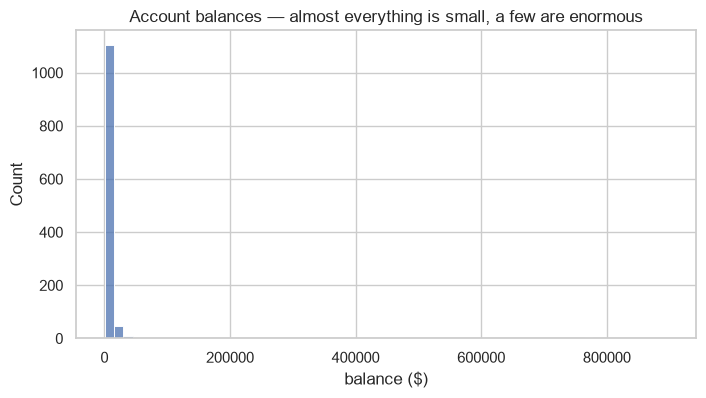

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=deposits, x="balance", bins=60, ax=ax)
ax.set_title("Account balances — almost everything is small, a few are enormous")
ax.set_xlabel("balance ($)")
plt.show()

That shape — a tall pile against the left wall and a long tail stretching right — is called
**right-skewed** (or positively skewed). It is the most common shape in money data of any kind:
balances, incomes, transaction sizes, claim amounts.

The picture explains the mean/median gap instantly, which is the general lesson: **plot first, then
compute.** A number can hide a shape; a shape cannot hide from a plot.

## 5 · Slicing: asking questions of subsets

Two operations do most of the work in pandas. First, selecting rows that meet a condition:

In [7]:
cds = deposits[deposits["product"] == "CD"]
print("CD accounts:", len(cds))
print(f"their mean balance: ${cds.balance.mean():,.0f}")

CD accounts: 179
their mean balance: $24,530


Second, `groupby` — "split into groups, compute something for each." This is the workhorse.

In [8]:
deposits.groupby("branch")["balance"].agg(["count", "mean", "median"]).round(0)

,count,mean,median
branch,,,
Logan,223,40608.0,3774.0
Ogden,447,17682.0,3960.0
Provo,350,22069.0,3826.0
St. George,180,23351.0,3887.0


Read that as: *for each branch, give me the count, mean, and median balance.* Notice that within
every single branch the mean still sits well above the median — the skew is a property of how money
is distributed, not an artefact of mixing branches together.

## Your turn

Three exercises. Try each one before opening the solution underneath it — the struggle is the part
that makes it stick. If you are stuck for more than five minutes, open it; you are not being graded.

**Exercise 1.** How many accounts are in the Provo branch, and what is their median balance?

In [9]:
# your code here

In [ ]:
provo = deposits[deposits["branch"] == "Provo"]
print("Provo accounts:", len(provo))
print(f"median balance: ${provo.balance.median():,.0f}")

**Exercise 2.** Use `groupby` to find the mean `tenure_years` for each `product`. Which product has
the longest-tenured customers?

In [11]:
# your code here

In [ ]:
print(deposits.groupby("product")["tenure_years"].mean().round(2).sort_values(ascending=False))
# CDs tend to be held by longer-tenured customers -- they are a commitment product.

**Exercise 3.** Draw a histogram of `tenure_years`. Is it skewed the same way `balance` was?

In [13]:
# your code here

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=deposits, x="tenure_years", bins=40, ax=ax)
ax.set_title("Customer tenure")
plt.show()

print(f"mean {deposits.tenure_years.mean():.2f} vs median {deposits.tenure_years.median():.2f}")
# Also right-skewed, but far more mildly -- the mean/median gap is small.
# Skew is a matter of degree, not a yes/no property.

## What you did today

- Loaded a CSV, checked its shape, summarised it, and plotted it — the four moves you will repeat all term.
- Learned that rows are **observations**, columns are **variables**, and `n` is the row count.
- Met `x̄` (sample mean) and saw *why* the mean and median can disagree badly.
- Learned the habit that matters most: **plot before you conclude.**

**Next:** `02_shape_center_spread.ipynb` — naming the shapes and measuring the spread.